In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [6]:
diabetes_data = pd.read_csv("diabetes (2).csv")

diabetes_data.sample(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
436,12,140,85,33,0,37.4,0.244,41,0
761,9,170,74,31,0,44.0,0.403,43,1
574,1,143,86,30,330,30.1,0.892,23,0
258,1,193,50,16,375,25.9,0.655,24,0
268,0,102,52,0,0,25.1,0.078,21,0


In [7]:
print("Dataset Shape :", diabetes_data.shape)

display(diabetes_data.describe())

diabetes_data.info()

Dataset Shape : (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [8]:
print("Missing Values")

diabetes_data.isna().sum()

print("\nDuplicate Rows :", diabetes_data.duplicated().sum())

Missing Values

Duplicate Rows : 0


In [9]:
feature_data = diabetes_data.drop(columns=["Outcome"])

target_data = diabetes_data["Outcome"]

In [10]:
train_features, test_features, train_labels, test_labels = train_test_split(
    feature_data,
    target_data,
    test_size=0.25,
    random_state=7,
    stratify=target_data,
    shuffle=True
)

In [11]:
normalizer = StandardScaler()

normalizer.fit(train_features)

train_features = normalizer.transform(train_features)

test_features = normalizer.transform(test_features)

In [12]:
network = Sequential()

network.add(Dense(
    24,
    activation="relu",
    input_shape=(train_features.shape[1],)
))

network.add(Dense(
    12,
    activation="relu"
))

network.add(Dense(
    6,
    activation="relu"
))

network.add(Dense(
    1,
    activation="sigmoid"
))

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
network.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [14]:
network.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 24)             │           216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │           300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │            78 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             7 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 601 (2.35 KB)

 Trainable params: 601 (2.35 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
import os

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

In [16]:
import tensorflow as tf

print(tf.__version__)
print(tf.config.list_physical_devices())

2.21.0
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [17]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

In [18]:
training_history = network.fit(
    train_features,
    train_labels,
    epochs=80,
    batch_size=32,
    validation_split=0.15,
    verbose=1
)

Epoch 1/80
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6155 - loss: 0.6605 - val_accuracy: 0.7126 - val_loss: 0.6085
Epoch 2/80
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7260 - loss: 0.6226 - val_accuracy: 0.7471 - val_loss: 0.5832
Epoch 3/80
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7526 - loss: 0.5895 - val_accuracy: 0.7931 - val_loss: 0.5600
Epoch 4/80
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7505 - loss: 0.5613 - val_accuracy: 0.7701 - val_loss: 0.5410
Epoch 5/80
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7566 - loss: 0.5401 - val_accuracy: 0.7816 - val_loss: 0.5222
Epoch 6/80
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7546 - loss: 0.5231 - val_accuracy: 0.7816 - val_loss: 0.5076
Epoch 7/80
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7587 - loss: 0.5105 - val_accuracy: 0.7816 - val_loss: 0.4962
Epoch 8/80
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7669 - loss: 0.5005 - val_accuracy: 0.7931 - val_loss:

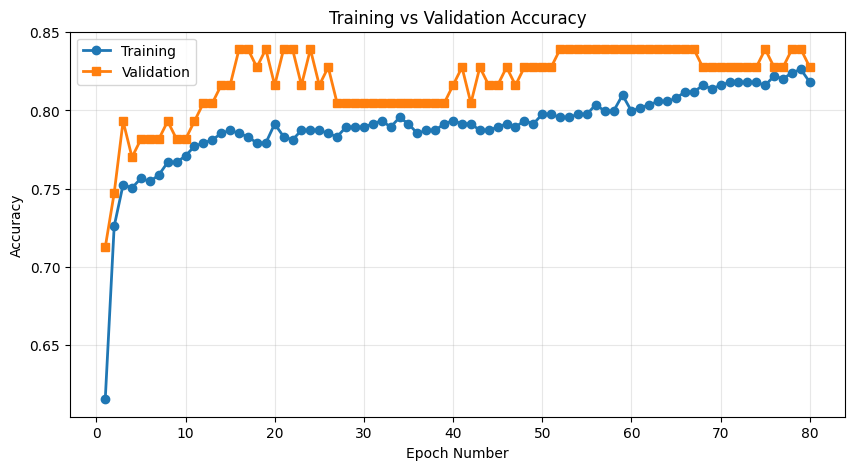

In [19]:
epochs = range(1, len(training_history.history["accuracy"]) + 1)

plt.figure(figsize=(10,5))

plt.plot(
    epochs,
    training_history.history["accuracy"],
    marker="o",
    linewidth=2,
    label="Training"
)

plt.plot(
    epochs,
    training_history.history["val_accuracy"],
    marker="s",
    linewidth=2,
    label="Validation"
)

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch Number")
plt.ylabel("Accuracy")
plt.grid(alpha=0.3)
plt.legend()

plt.show()

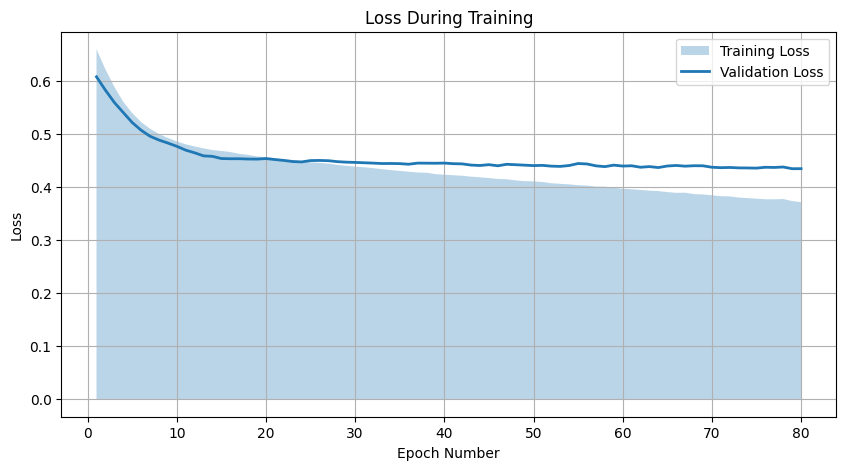

In [20]:
plt.figure(figsize=(10,5))

plt.fill_between(
    epochs,
    training_history.history["loss"],
    alpha=0.3,
    label="Training Loss"
)

plt.plot(
    epochs,
    training_history.history["val_loss"],
    linewidth=2,
    label="Validation Loss"
)

plt.title("Loss During Training")
plt.xlabel("Epoch Number")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()

plt.show()

In [21]:
test_loss, test_accuracy = network.evaluate(
    test_features,
    test_labels,
    verbose=0
)

print(f"Testing Loss : {test_loss:.4f}")
print(f"Testing Accuracy : {test_accuracy:.4f}")

Testing Loss : 0.4622
Testing Accuracy : 0.7448


In [22]:
prediction_probability = network.predict(test_features, verbose=0)

predicted_labels = np.where(prediction_probability >= 0.5, 1, 0)

In [23]:
final_accuracy = accuracy_score(
    test_labels,
    predicted_labels
)

print("Accuracy Score :", final_accuracy)

Accuracy Score : 0.7447916666666666


In [24]:
conf_matrix = confusion_matrix(
    test_labels,
    predicted_labels
)

print(conf_matrix)

[[103  22]
 [ 27  40]]


In [25]:
print(
    classification_report(
        test_labels,
        predicted_labels
    )
)

              precision    recall  f1-score   support

           0       0.79      0.82      0.81       125
           1       0.65      0.60      0.62        67

    accuracy                           0.74       192
   macro avg       0.72      0.71      0.71       192
weighted avg       0.74      0.74      0.74       192



In [26]:
prediction_result = pd.DataFrame({
    "Actual Value": test_labels.reset_index(drop=True),
    "Predicted Value": predicted_labels.flatten()
})

prediction_result.head(15)

,Actual Value,Predicted Value
0,1,1
1,1,0
2,0,1
3,1,1
4,1,1
5,0,0
6,0,0
7,1,1
8,1,1
9,0,0
